<a href="https://colab.research.google.com/github/jaeheechillin3/pytorch_projects/blob/main/autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports and setup

In [42]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [43]:
SEED = 1000
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

In [44]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Device: {device}")

Device: cuda


## Load MNIST dataset

In [45]:
BATCH_SIZE = 256
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
LATENT_DIMS = [2, 8, 24]

transform = transforms.ToTensor()

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Define autoencoder

In [46]:
class Autoencoder(nn.Module):
  def __init__(self, latent_dim):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 256),
        nn.ReLU(),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Linear(64, latent_dim),
    )

    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 256),
        nn.ReLU(),
        nn.Linear(256, 28*28),
        nn.Sigmoid(),
        nn.Unflatten(1, (1, 28, 28)),
    )

  def encode(self, x):
    return self.encoder(x)

  def decode(self, z):
    return self.decoder(z)

  def forward(self, x):
    return self.decode(self.encode(x))

## Train

In [47]:
def train_autoencoder(model, loader, epochs):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    criterion = nn.MSELoss()
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for images, _ in loader:
            images = images.to(device)

            reconstructions = model(images)
            loss = criterion(reconstructions, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)

        epoch_loss = total_loss / len(loader.dataset)
        history.append(epoch_loss)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} "
            f"| MSE: {epoch_loss:.6f}"
        )

    return history

In [48]:
models = {}
histories = {}

for latent_dim in LATENT_DIMS:
    print(f"\nTraining model with latent_dim={latent_dim}")

    model = Autoencoder(latent_dim).to(device)

    history = train_autoencoder(
        model,
        train_loader,
        NUM_EPOCHS,
    )

    models[latent_dim] = model
    histories[latent_dim] = history



Training model with latent_dim=2
Epoch 01/10 | MSE: 0.069904
Epoch 02/10 | MSE: 0.053115
Epoch 03/10 | MSE: 0.050269
Epoch 04/10 | MSE: 0.047286
Epoch 05/10 | MSE: 0.045356
Epoch 06/10 | MSE: 0.044269
Epoch 07/10 | MSE: 0.043453
Epoch 08/10 | MSE: 0.042785
Epoch 09/10 | MSE: 0.042243
Epoch 10/10 | MSE: 0.041732

Training model with latent_dim=8
Epoch 01/10 | MSE: 0.069638
Epoch 02/10 | MSE: 0.036760
Epoch 03/10 | MSE: 0.028853
Epoch 04/10 | MSE: 0.026022
Epoch 05/10 | MSE: 0.024626
Epoch 06/10 | MSE: 0.023603
Epoch 07/10 | MSE: 0.022786
Epoch 08/10 | MSE: 0.022174
Epoch 09/10 | MSE: 0.021596
Epoch 10/10 | MSE: 0.021151

Training model with latent_dim=24
Epoch 01/10 | MSE: 0.068281
Epoch 02/10 | MSE: 0.034413
Epoch 03/10 | MSE: 0.027507
Epoch 04/10 | MSE: 0.023346
Epoch 05/10 | MSE: 0.020853
Epoch 06/10 | MSE: 0.018806
Epoch 07/10 | MSE: 0.017464
Epoch 08/10 | MSE: 0.016391
Epoch 09/10 | MSE: 0.015340
Epoch 10/10 | MSE: 0.014443


## Plot results

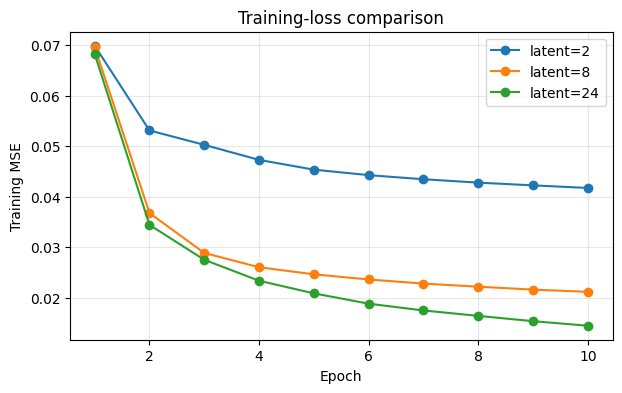

In [49]:
plt.figure(figsize=(7, 4))

for latent_dim, history in histories.items():
    plt.plot(
        range(1, NUM_EPOCHS + 1),
        history,
        marker="o",
        label=f"latent={latent_dim}",
    )

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Training-loss comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

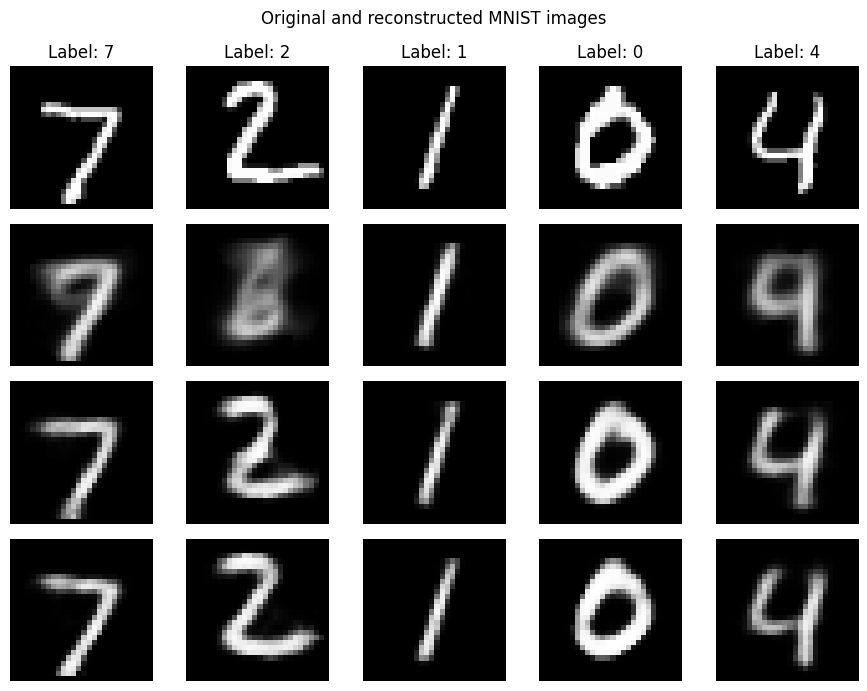

In [50]:
test_images, test_labels = next(iter(test_loader))
originals = test_images[:5]

fig, axes = plt.subplots(
    1 + len(LATENT_DIMS),
    5,
    figsize=(9, 7),
)

# Original images
for i in range(5):
    axes[0, i].imshow(
        originals[i, 0],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[0, i].set_title(
        f"Label: {test_labels[i].item()}"
    )
    axes[0, i].axis("off")

axes[0, 0].set_ylabel("Original")


# Reconstructed images
for row, latent_dim in enumerate(LATENT_DIMS, start=1):
    model = models[latent_dim]
    model.eval()

    with torch.no_grad():
        reconstructions = model(
            originals.to(device)
        ).cpu()

    for i in range(5):
        axes[row, i].imshow(
            reconstructions[i, 0],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, i].axis("off")

    axes[row, 0].set_ylabel(
        f"Latent {latent_dim}"
    )

plt.suptitle("Original and reconstructed MNIST images")
plt.tight_layout()
plt.show()